In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from flax import nnx
import optax

import jaxpm
from jaxpm import hpm, camels, training, plotting, diagnostics, objectives
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.splines import NeuralSplineFourierFilterNNX
from jaxpm.nn import MLP, ConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

mesh_shape = [mesh_per_dim] * 3

# with_latent = True
with_latent = False

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64.h5


In [5]:
# for camels_dict in [train_dict, vali_dict]:
#     diagnostics.run_simulations(
#         camels_dict,
#         mesh_per_dim,
#         dt0=dt0,
#         i_plot=i_plot,
#         plot_dm=True,
#         plot_gas=False,
#     )

In [6]:
cosmo = train_dict["cosmo"]
solve_ode = training.get_ode_solver(mesh_per_dim, cosmo)
train_step = training.get_train_step(mesh_per_dim, cosmo)

# loss

### CAMELS ground truth

In [7]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

# fields
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
deltas_dm = rhos_dm/rhos_dm.mean() - 1

rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
deltas_gas = rhos_gas/rhos_gas.mean() - 1

# power spectrum
_, cls_dm = objectives.vpower_spectrum(deltas_dm)
_, cls_gas = objectives.vpower_spectrum(deltas_gas)

# gravity correction

In [8]:
gravity_model = NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))
gravity_loss_fn = ParticleLoss(mesh_per_dim, w_pos=1.0, w_cls=1.0, loss_type="huber", robust_scale=mesh_per_dim//8, k_max=2)

checkpoint_file = os.path.join(os.getcwd(), f"checkpoints/gravity_model_code={CODE},parts={parts_per_dim},mesh={mesh_per_dim}.jx")
gravity_model.load(checkpoint_file)

Checkpoint loaded from /global/u2/a/athomsen/flatiron/JaxPM/dev/hpm/sims/checkpoints/gravity_model_code=SIMBA,parts=64,mesh=64.jx


/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## training

In [9]:
total_steps = 300
learning_rate = 1e-3
clip_norm = 1

gravity_optimizer = nnx.ModelAndOptimizer(
    gravity_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grad_norms = []

In [10]:
# # evaluating the loss for all snapshots is computationally feasible
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i0 = 0
#     y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
#     t0 = scales[i0]
    
#     loss, grad_norm = train_step(
#         gravity_loss_fn,
#         gravity_optimizer, 
#         y0, 
#         t0,
#         scales,
#         ref_poss=dm_poss, 
#         ref_cls=cls_dm,
#         ref_deltas=deltas_dm,
#         gravity_model=gravity_model,
#         pressure_model=None,
#         model_to_train="gravity",
#     )

#     losses.append(loss)
#     pbar.set_description(f"Loss: {loss:.4f}")

# fig, ax = plt.subplots()
# ax.plot(losses)
# ax.set(yscale="log")

In [11]:
# gravity_model.save(checkpoint_file)

In [12]:
# i_plot = np.linspace(0, scales.shape[0]-1, 4, dtype=int)
# for camels_dict in [train_dict, vali_dict]:
#     diagnostics.run_simulations(
#         camels_dict,
#         mesh_per_dim,
#         gravity_model=gravity_model,
#         nt=2,
#         i_init=0,
#         i_plot=i_plot,
#         plot_dm=True,
#         plot_gas=False,
#     )

# pressure correction

## model

### MLP

In [13]:
# pressure_model = MLP(
#     d_in=5 + with_latent,
#     d_out=1 + with_latent, 
#     # d_hidden=16, 
#     d_hidden=64, 
#     # d_hidden=128,
#     # d_hidden=256,
#     n_hidden=4, 
#     # n_hidden=2, 
#     # dropout_rate=0.01,
#     dropout_rate=0.0,
#     rngs=nnx.Rngs(0),
#     norm_type="layer",
#     # norm_type="batch",
#     activation=jax.nn.swish,
#     k_filter="spline",
# )

# # learning_rate = 1e-3
# learning_rate = 1e-4
# # learning_rate = 1e-5

### CNN

In [72]:
pressure_model = ConditionedCNN(
    d_in=4 + with_latent,
    d_out=1 + with_latent,
    d_hidden=64,
    # d_hidden=16,
    # n_hidden=2,
    n_hidden=4,
    # n_hidden=8,
    kernel_size=(3, 3, 3),
    # kernel_size=(5, 5, 5),
    rngs=nnx.Rngs(0),
    norm_type="layer",
    activation=jax.nn.swish,
    # activation=jax.nn.relu,
    use_residual=True,
)

learning_rate = 1e-4
# learning_rate = 1e-5

In [73]:
# checkpoint_file = os.path.join(os.getcwd(), f"checkpoints/pressure_code={CODE},parts={parts_per_dim},mesh={mesh_per_dim}")
# checkpoint_file += "_cnn_default_v0"
# checkpoint_file += ".jx"
# pressure_model.load(checkpoint_file)

## training

In [74]:
def train_step_wrapper(i0=0, i_ref=None, aug_key=None):
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
    if with_latent:
        if isinstance(pressure_model, jaxpm.nn.MLP):
            y0 += (jnp.ones((parts_per_dim**3, 1)),)
        elif isinstance(pressure_model, jaxpm.nn.ConditionedCNN):
            y0 += (jnp.ones(mesh_shape + [1]),)
        else:
            raise NotImplementedError
    t0 = scales[i0]

    if all_steps := (i_ref is None):
        i_ref = np.arange(i0, len(scales))

    loss, grad = train_step(
        pressure_loss_fn,
        pressure_optimizer,
        y0,
        t0,
        ref_t=scales[i_ref],
        ref_poss=gas_poss[i_ref],
        ref_vels=gas_vels[i_ref],
        ref_cls=cls_gas[i_ref],
        ref_deltas=deltas_gas[i_ref],
        pressure_model=pressure_model,
        # gravity_model=gravity_model,
        gravity_model=None,
        model_to_train="pressure",
        aug_key=aug_key,
        tstep=scales[(t0 <= scales) & (scales <= scales[i_ref[-1]])],
        nt=2,
    )

    losses.append(float(loss))
    grads.append(float(grad))
    pbar.set_description(f"[{i_ref[0]}, {i_ref[-1]}], Loss: {loss:.4e}, Grad: {grad:.4e}")


def plot_training(losses, grad_norms):
    fig, ax = plt.subplots(figsize=(6, 10), nrows=2, sharex=True)
    ax[0].plot(losses)
    ax[0].set(yscale="log", title="loss")

    ax[1].plot(grad_norms)
    ax[1].set(yscale="log", title="norm(grad)")


In [75]:
def dual_train_step_wrapper(i0=0, i_ref=None, aug_key=None):
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
    if with_latent:
        if isinstance(pressure_model, jaxpm.nn.MLP):
            y0 += (jnp.ones((parts_per_dim**3,1)),)
        elif isinstance(pressure_model, jaxpm.nn.ConditionedCNN):
            y0 += (jnp.ones(mesh_shape + [1]),)
        else:
            raise NotImplementedError
    t0 = scales[i0]
    
    if all_steps := (i_ref is None):
        i_ref = np.arange(i0, len(scales))

    def single_train_step(loss_fn, optimizer, model_to_train):
        ref_t=scales[i_ref]
        if model_to_train == "pressure":
            ref_poss = gas_poss[i_ref]
            ref_vels = gas_vels[i_ref]
            ref_cls = cls_gas[i_ref]
            ref_deltas = deltas_gas[i_ref]
        elif model_to_train == "gravity":
            ref_poss = dm_poss[i_ref]
            ref_vels = dm_vels[i_ref]
            ref_cls = cls_dm[i_ref]
            ref_deltas = deltas_dm[i_ref]

        return train_step(
            loss_fn,
            optimizer, 
            y0, 
            t0,
            ref_t=ref_t,
            ref_poss=ref_poss, 
            ref_vels=ref_vels,
            ref_cls=ref_cls,
            ref_deltas=ref_deltas,
            pressure_model=pressure_model,
            gravity_model=gravity_model,
            model_to_train=model_to_train,
            aug_key=aug_key,
            tstep=scales[(t0 <= scales) & (scales <= scales[i_ref[-1]])],
        )
    
    pressure_loss, _ = single_train_step(pressure_loss_fn, pressure_optimizer, "pressure")
    gravity_loss, _ = single_train_step(gravity_loss_fn, gravity_optimizer, "gravity")

    pressure_losses.append(float(pressure_loss))
    gravity_losses.append(float(gravity_loss))
    
    pbar.set_description(f"[{i_ref[0]}, {i_ref[-1]}], P loss = {pressure_loss:.4e}, g loss = {gravity_loss:.4e}")

def plot_dual_training(losses1, losses2):
    fig, ax = plt.subplots(figsize=(6,10), nrows=2, sharex=True)
    ax[0].plot(losses1)
    ax[0].set(yscale="log", title="loss1")
    
    ax[1].plot(losses2)
    ax[1].set(yscale="log", title="loss2")


### loss

In [76]:
pressure_loss_fn = ParticleLoss(
    mesh_per_dim,
    w_pos=1.0,
    w_vel=0.01,
    w_cls=0.1,
    # w_cross=10.0,
    w_snapshot=0.0,
    k_max=2,
    loss_type="huber",
    robust_scale=mesh_per_dim//16,
    cutoff_quantile=0.95,
)

In [77]:
# pressure_loss_fn = FieldLoss(
#     mesh_per_dim,
#     w_field=1.0,
#     w_cls=0.1,
#     k_max=2,
#     use_arcsinh=False,
# )

### optimizer

In [78]:
total_steps = 100

# learning_rate = optax.warmup_cosine_decay_schedule(
#     init_value=1e-5,
#     peak_value=1e-4,
#     end_value=0.0,
#     warmup_steps=total_steps//5,
#     decay_steps=total_steps - total_steps//5, 
# )
# learning_rate = 1e-5
clip_norm = 1
pressure_optimizer = nnx.ModelAndOptimizer(
    pressure_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grads = []

pressure_losses = []
gravity_losses = []

## loss snapshots

In [79]:
i0 = 0

### all

In [80]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     train_step_wrapper(i0=i0)
# plot_training(losses, grads)

### subset

  0%|          | 0/100 [00:00<?, ?it/s]

Applying augmentations (random flips and 90 degree rotations)
Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
Using particle loss
w_pos = 1.0, loss = huber, scale = 4.0
w_vel = 0.01, loss = huber, scale = 16.0
w_cls = 0.1, k_max = 2, k_type = step


[8, 33], Loss: 1.4055e+00, Grad: 5.6106e+00: 100%|██████████| 100/100 [06:33<00:00,  3.93s/it]


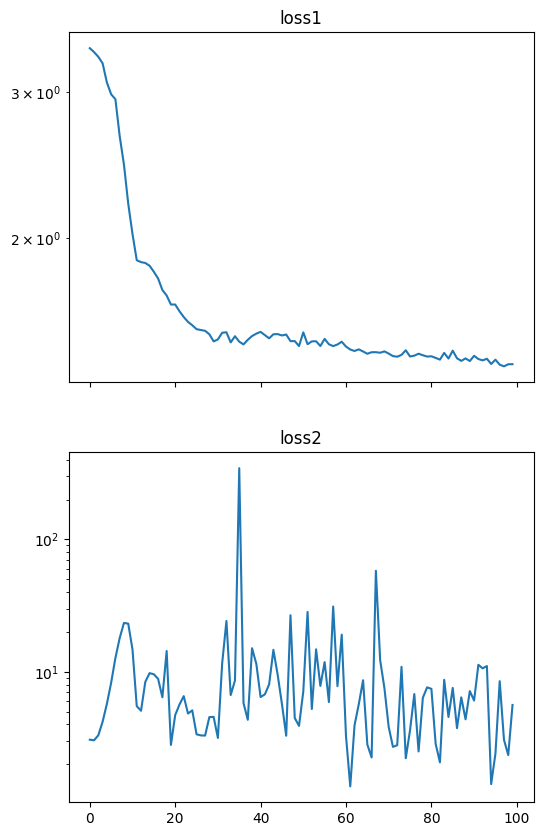

In [81]:
key = jax.random.key(71)

i_ref = np.linspace(i0, 33, 5, dtype=int)[1:]
# i_ref = jnp.array([-1])
for i in (pbar := tqdm.tqdm(range(total_steps))):
    key, subkey = jax.random.split(key)
    train_step_wrapper(i0=i0, i_ref=i_ref, aug_key=subkey)
    
plot_dual_training(losses, grads)

In [82]:
# key = jax.random.key(71)

# i_ref = np.linspace(i0, 33, 5, dtype=int)[1:]
# # i_ref = jnp.array([-1])
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     key, subkey = jax.random.split(key)
#     dual_train_step_wrapper(i0=i0, i_ref=i_ref, aug_key=subkey)
    
# plot_dual_training(pressure_losses, gravity_losses)

### curriculum

In [83]:
# i0 = 0
# i_step = 4

# # for i1 in range(i0+i_step, 31 + i_step, i_step):
# for i1 in np.arange(i0+i_step, 33 + i_step, i_step):
#     i_ref = np.arange(i0, np.minimum(i1, 34))
#     print(i_ref)
    
#     # for j in (pbar := tqdm.tqdm(range(total_steps))):
#     #     train_step_wrapper(i0=i0, i_ref=i_ref)
        
# # plot_training(losses, grad_norms)

### checkpointing

In [84]:
# checkpoint_file = os.path.join(os.getcwd(), f"checkpoints/pressure_code={CODE},parts={parts_per_dim},mesh={mesh_per_dim}")
# checkpoint_file += "_cnn_default_v0"
# checkpoint_file += ".jx"
# pressure_model.save(checkpoint_file)

# testing

Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:10<00:00,  2.71s/it]


Using particle loss
w_pos = 1.0, loss = huber, scale = 4.0
pos_loss = 5.1830e-01
w_vel = 0.01, loss = huber, scale = 16.0
vel_loss = 1.8290e-02
w_cls = 0.1, k_max = 2, k_type = step
cls_loss = 9.2005e-02
Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
dark matter and gas
dark matter and gas
Solving ODE in 100 steps (StepTo with 2 steps between ts)
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable
dark matter and gas
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:10<00:00,  2.70s/it]


Using particle loss
w_pos = 1.0, loss = huber, scale = 4.0
pos_loss = 6.0647e-01
w_vel = 0.01, loss = huber, scale = 16.0
vel_loss = 1.9927e-02
w_cls = 0.1, k_max = 2, k_type = step
cls_loss = 1.0637e-01


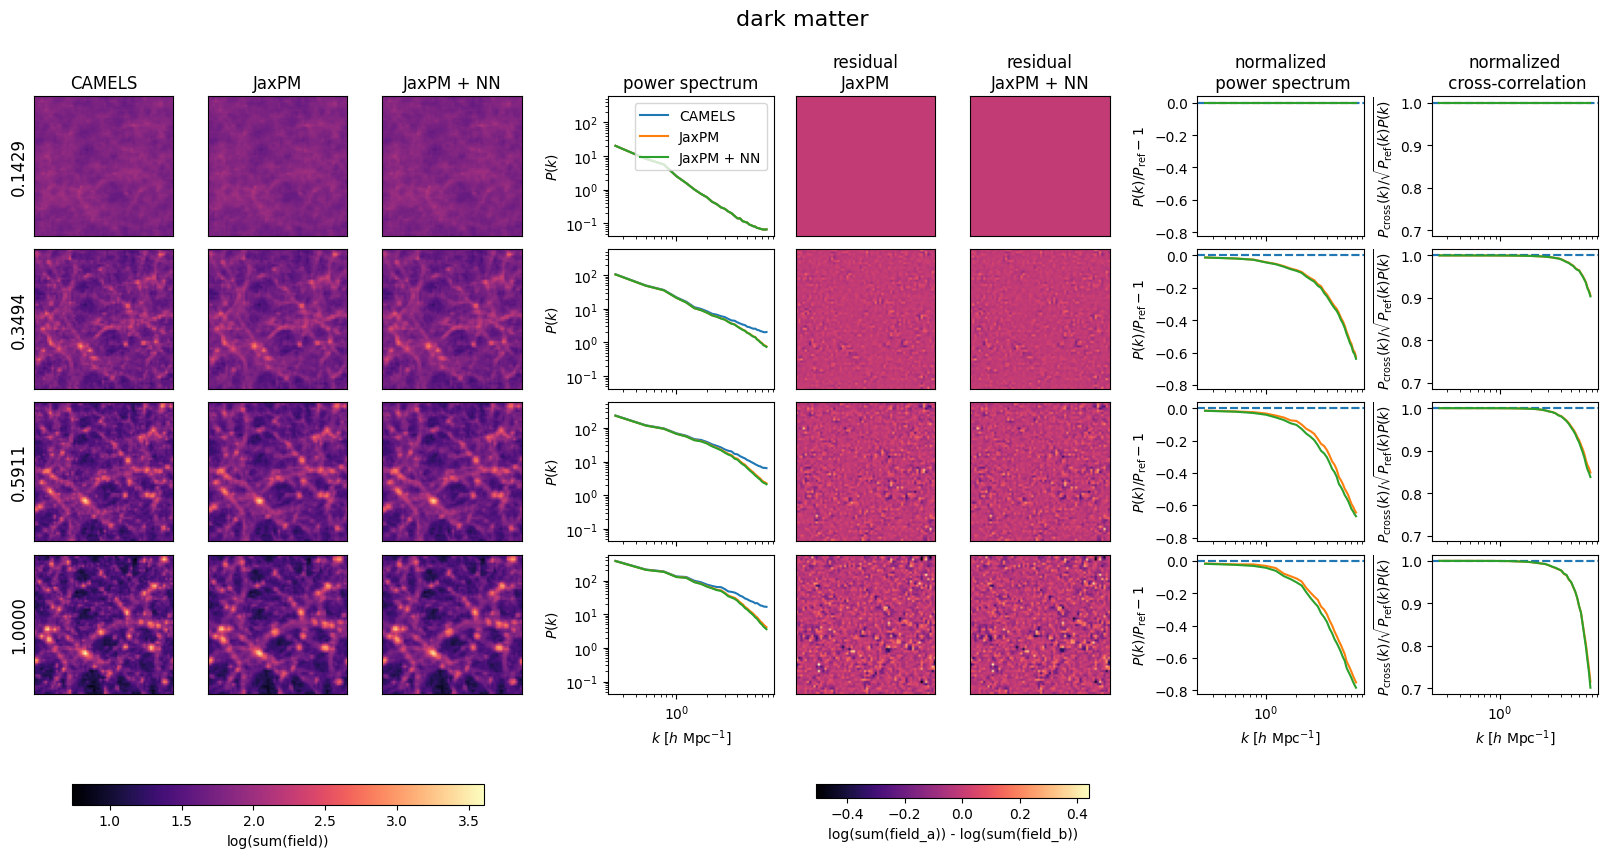

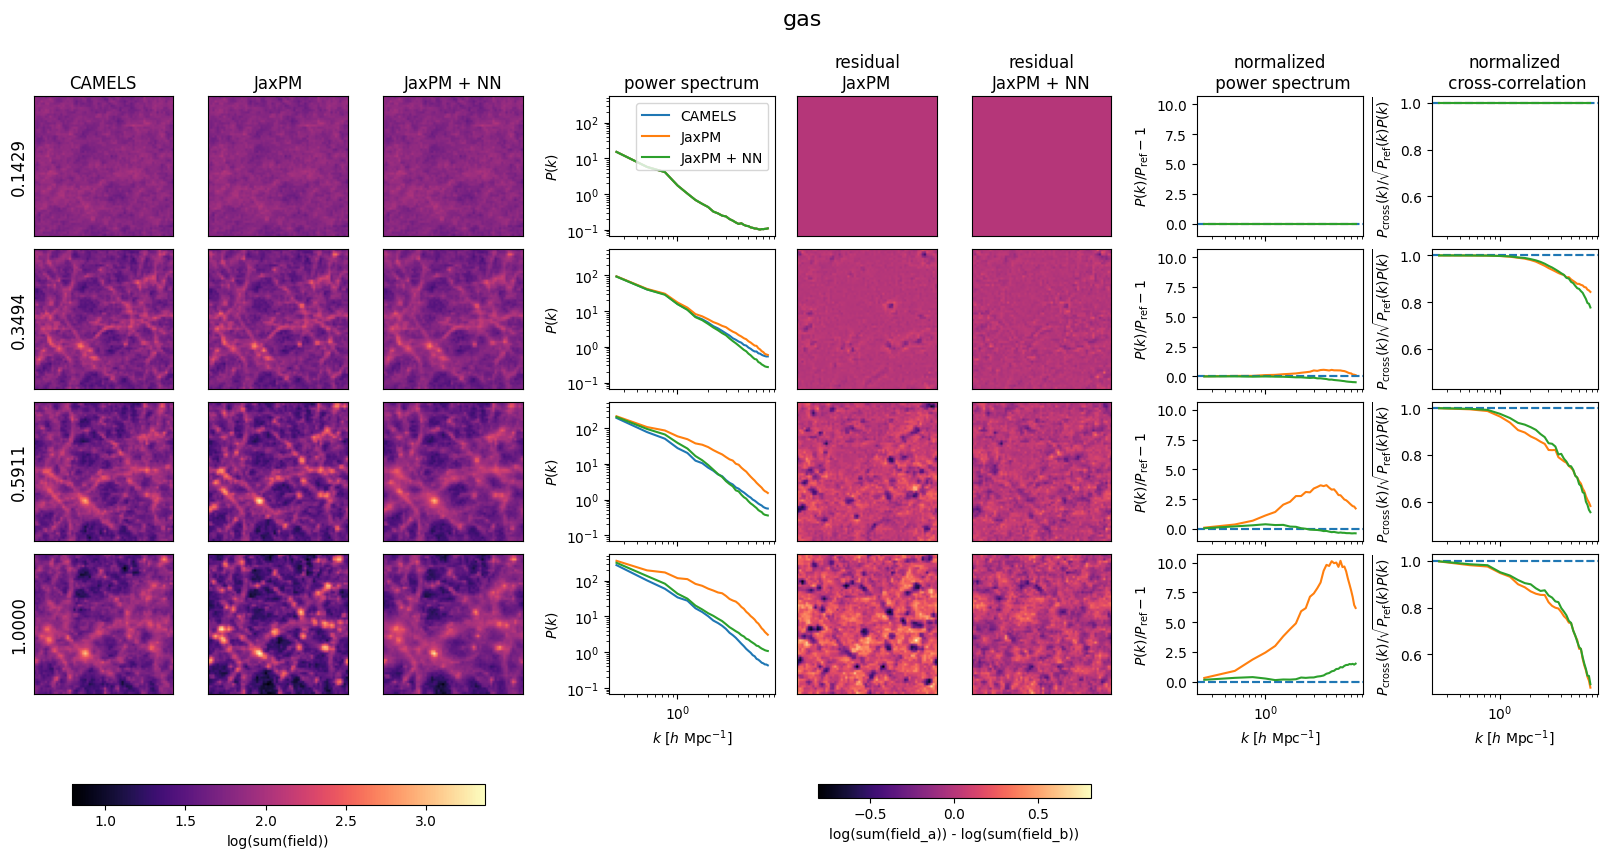

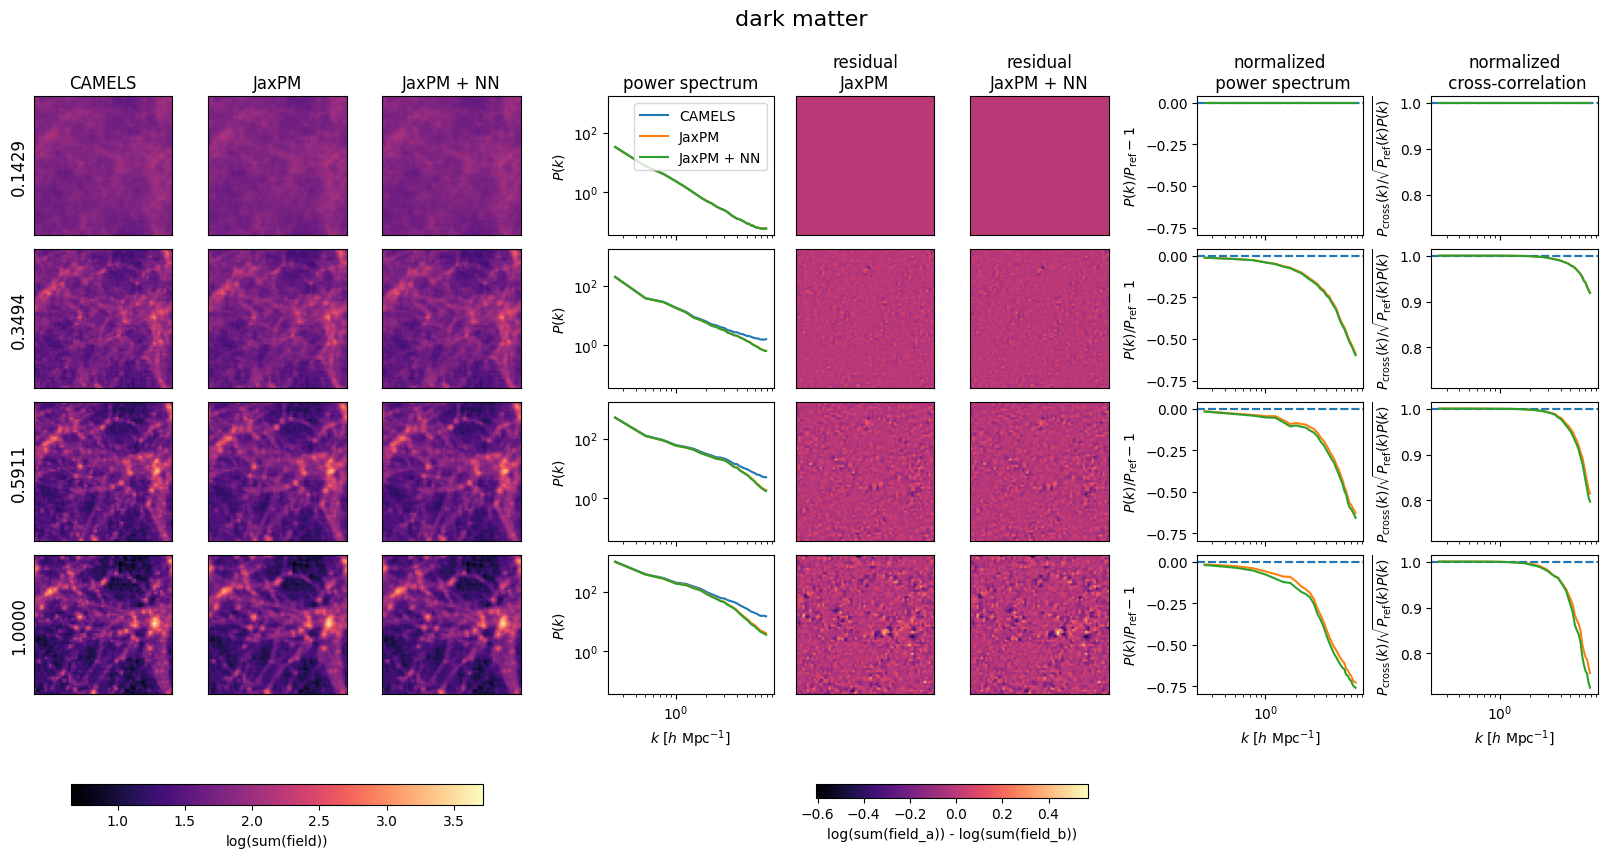

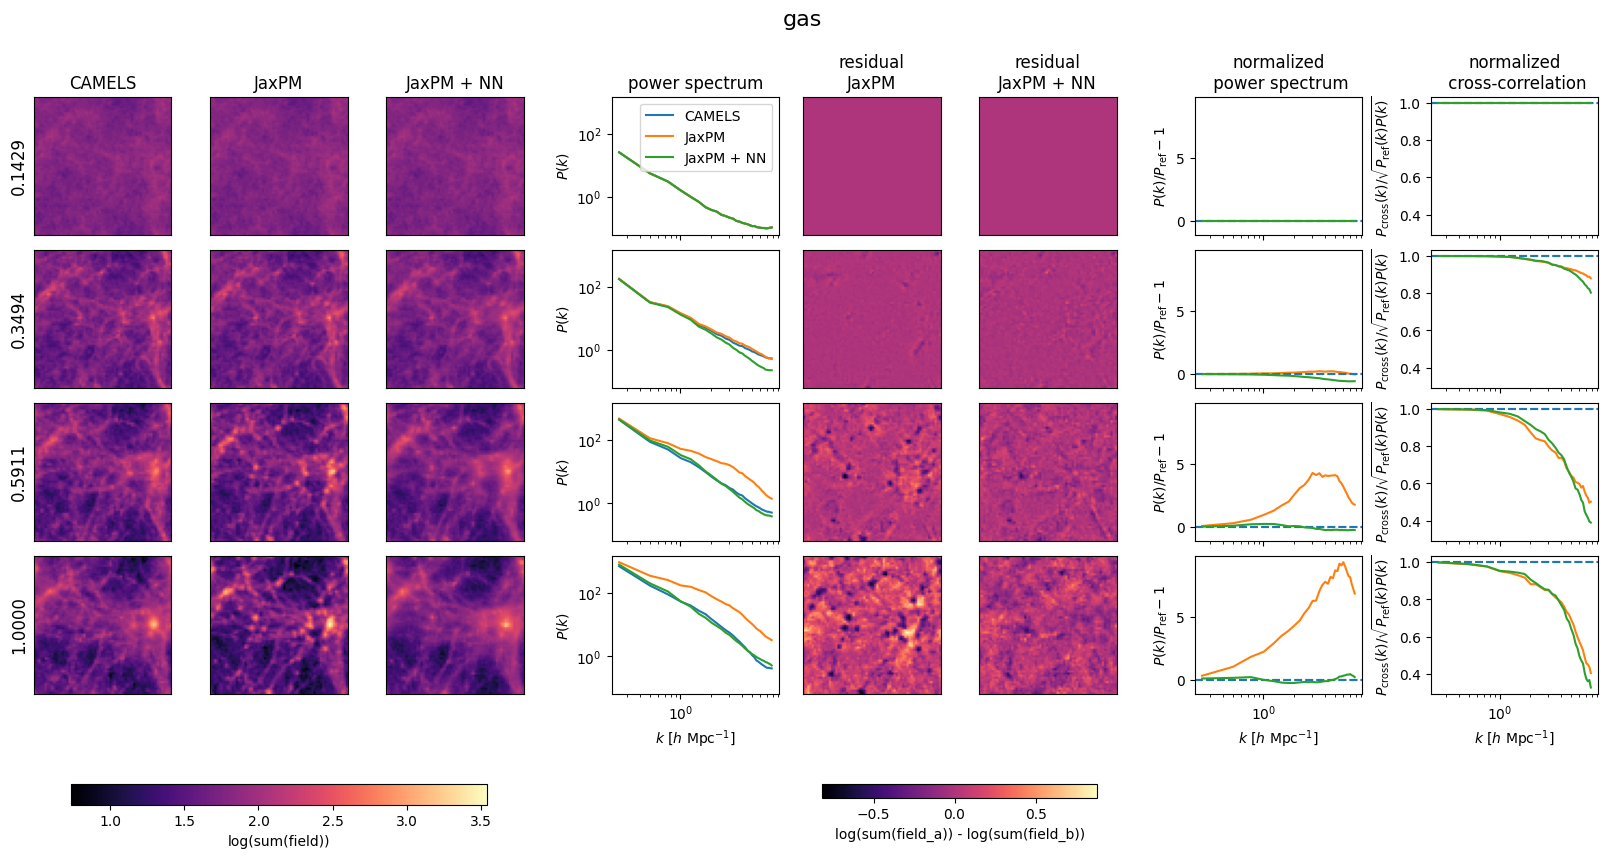

In [86]:
i_plot = np.linspace(i0, 33, 4, dtype=int)
# i_plot = np.linspace(i0, 33, 8, dtype=int)
# i_plot = np.linspace(i0, 33, 8, dtype=int)
# i_plot = np.linspace(i0, 33, 2, dtype=int)
# i_plot = [-1]
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        # gravity_model=gravity_model,
        pressure_model=pressure_model, 
        i_init=i0,
        i_plot=i_plot,
        nt=2,
        plot_dm=True,
        plot_gas=True,
        with_latent=with_latent,
        plot_latent=with_latent,
        loss_fn=pressure_loss_fn,
    )

In [26]:
stop

NameError: name 'stop' is not defined

# temp

In [ ]:
from jaxpm import augmentations
key = jax.random.key(11)

In [ ]:
deltas_dm = jnp.array(deltas_dm)

In [ ]:
jit_rot = jax.jit(augmentations.rot_flip_3d)
temp = jit_rot(key, mesh_per_dim, field=deltas_dm)

In [ ]:
%%timeit
temp = jit_rot(key, mesh_per_dim, field=deltas_dm)

In [ ]:
temp = augmentations.rot_flip_3d(key, mesh_per_dim, field=deltas_dm[0])

In [ ]:
temp = augmentations.field_flip_3d(jnp.array(deltas_dm), key)

In [ ]:
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

In [ ]:
poss, vels = jnp.array(dm_poss), jnp.array(dm_vels)



In [ ]:
%%timeit
aug_poss, aug_vels = augment.particle_flip_3d(poss, vels, mesh_per_dim, key)

In [ ]:
jit_flip = jax.jit(augment.particle_flip_3d)
aug_poss, aug_vels = jit_flip(poss, vels, mesh_per_dim, key)

In [ ]:
%%timeit
aug_poss, aug_vels = jit_flip(poss, vels, mesh_per_dim, key)

In [ ]:
aug_poss.shape

In [ ]:
dm_poss.shape

In [ ]:
pos, vel = jnp.array(dm_poss[-1]), jnp.array(dm_vels[-1])

key = jax.random.key(11)
aug_pos, aug_vel = augment.particle_flip_3d(pos, vel, mesh_shape, key)

In [ ]:
aug_pos

In [ ]:
pos